#### **Clone git repo and install requirements**

In [1]:
import os

#check if the repository folder already exists on the Colab disk
#(for if we've pushed new changes from remote repo to git and pull them on here)
if os.path.exists('/content/QML4EO-reproduction'):
    print("Repo found! Pulling latest changes from GitHub..")
    %cd /content/QML4EO-reproduction
    !git pull
else:
    print("Cloning repo for the first time..")
    %cd /content
    !git clone https://github.com/yeshapan/QML4EO-reproduction.git
    %cd QML4EO-reproduction

#install required dependencies
!pip install -r requirements.txt -q

Cloning repo for the first time..
/content
Cloning into 'QML4EO-reproduction'...
remote: Enumerating objects: 72, done.
remote: Counting objects: 100% (72/72), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 72 (delta 25), reused 60 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (72/72), 6.81 MiB | 15.96 MiB/s, done.
Resolving deltas: 100% (25/25), done.
/content/QML4EO-reproduction
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 103.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import torch
from src.baselines.cnn import set_seed, train_baseline
from src.utils.data_loader import get_eurosat_dataloaders
from src.models.hqcnn import HybridQCNN

#setup device to use the T4 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware utilized: {device}")

Hardware utilized: cuda


#### **Load Data**

In [3]:
#load data (keeping 64x64 to match classical baseline comparison)
train_loader, val_loader, classes = get_eurosat_dataloaders(
    data_dir="./data",
    batch_size=32,
    img_size=64
)

Downloading/Loading EuroSAT dataset into ./data...


100%|██████████| 94.3M/94.3M [00:00<00:00, 104MB/s]


Dataset loaded successfully!
Total images: 27000 | Training: 21600 | Validation: 5400
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


#### **Initialize + Train the Hybrid Quantum Model**

In [6]:
#define rigorous test parameters
SEEDS = [42, 100, 2026]
EPOCHS = 15

#containers to hold metrics for statistical analysis
all_train_losses = []
all_val_accs = []

print("\nStarting Rigorous Hybrid Quantum Training:")

for seed in SEEDS:
    print(f"\n TRAINING SEED: {seed} ")

    #lock the randomness for this specific run
    set_seed(seed)

    #initialize the hybrid quantum model (4 qubits, 1 layer)
    model = HybridQCNN(num_classes=len(classes), num_qubits=4, num_layers=1)
    model = model.to(device)

    #execute the training loop
    history = train_baseline(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=EPOCHS,
        lr=0.001,
        device=device
    )

    #save the full array of metrics for this seed
    all_train_losses.append(history['train_loss'])
    all_val_accs.append(history['val_acc'])

import numpy as np

#convert lists to numpy arrays to easily calculate mean and standard deviation
acc_array = np.array(all_val_accs)
loss_array = np.array(all_train_losses)

mean_acc = np.mean(acc_array, axis=0)
std_acc = np.std(acc_array, axis=0)

#calculate total trainable parameters once
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters (Hybrid QCNN): {total_params:,}")

#report the final rigorous metric (using the literal ± symbol)
print(f"Final Hybrid Baseline: {mean_acc[-1]:.2f}% ± {std_acc[-1]:.2f}%")


Starting Rigorous Hybrid Quantum Training:

 TRAINING SEED: 42 


Epoch 1/15 [Train]: 100%|██████████| 675/675 [00:24<00:00, 27.01it/s, loss=1.4813]


Epoch 1 Summary -> Train Loss: 1.8669 | Val Accuracy: 39.50%


Epoch 2/15 [Train]: 100%|██████████| 675/675 [00:24<00:00, 27.08it/s, loss=1.5696]


Epoch 2 Summary -> Train Loss: 1.4874 | Val Accuracy: 41.63%


...

Epoch 13 Summary -> Train Loss: 0.9746 | Val Accuracy: 61.07%


Epoch 14/15 [Train]: 100%|██████████| 675/675 [00:25<00:00, 26.59it/s, loss=0.8198]


Epoch 14 Summary -> Train Loss: 0.9564 | Val Accuracy: 63.02%


Epoch 15/15 [Train]: 100%|██████████| 675/675 [00:25<00:00, 26.17it/s, loss=0.8760]


Epoch 15 Summary -> Train Loss: 0.9387 | Val Accuracy: 64.37%

Total Trainable Parameters (Hybrid QCNN): 5,274
Final Hybrid Baseline: 66.08% ± 2.42%


**Analysis (Hybrid-quantum benchmark)**

Running 15 epochs across 3 seeds reveals the exact cost and capability of our minimal quantum layer.

* The model reached a mean accuracy of 66.08% with a standard deviation of ± 2.42%.
* This high variance shows that quantum loss landscapes are highly non-convex and highly sensitive to weight initialization
* Compressing 32 classical feature channels into a 4-qubit state forces a steep drop in accuracy
* The hybrid model performs about 13% worse than the classical floor because a 1-layer ansatz lacks the necessary expressivity.
* Training time effectively doubled from 13 seconds to 25 seconds per epoch
* This highlights the severe simulation penalty of calculating quantum state vectors on classical hardware.

**The Parameter Discrepancy: Why is this Quantum Model (with 4 qubits) smaller than baseline CNN model?**

It is counter-intuitive that adding a quantum circuit reduces the total parameter count (5,418 classical vs 5,274 hybrid). This occurs due to the **information bottleneck** required to fit classical data into a small quantum state.

* **Classical CNN Final Layers (330 parameters):**
    * The fully connected layer maps 32 channels directly to 10 classes: (32 x 10 weights) + 10 biases = 330 parameters.

* **Hybrid QCNN Final Layers (186 parameters):**
    * **Bottleneck Layer:** Maps 32 channels down to 4 qubits: (32 x 4 weights) + 4 biases = 132 parameters.
    * **Quantum Ansatz:** 1 layer across 4 qubits requires 4 parameters (one trainable rotation per qubit).
    * **Final Classification Layer:** Maps 4 qubits to 10 classes: (4 x 10 weights) + 10 biases = 50 parameters

* **Math:** 330 - 186 = 144
    Subtracting 144 from the classical total of 5,418 yields exactly 5,274 trainable parameters. The lower accuracy (47.56%) is a direct result of forcing the model to compress its learned features through this tiny 4-qubit bottleneck in only 5 epochs.

#### **Visualization**

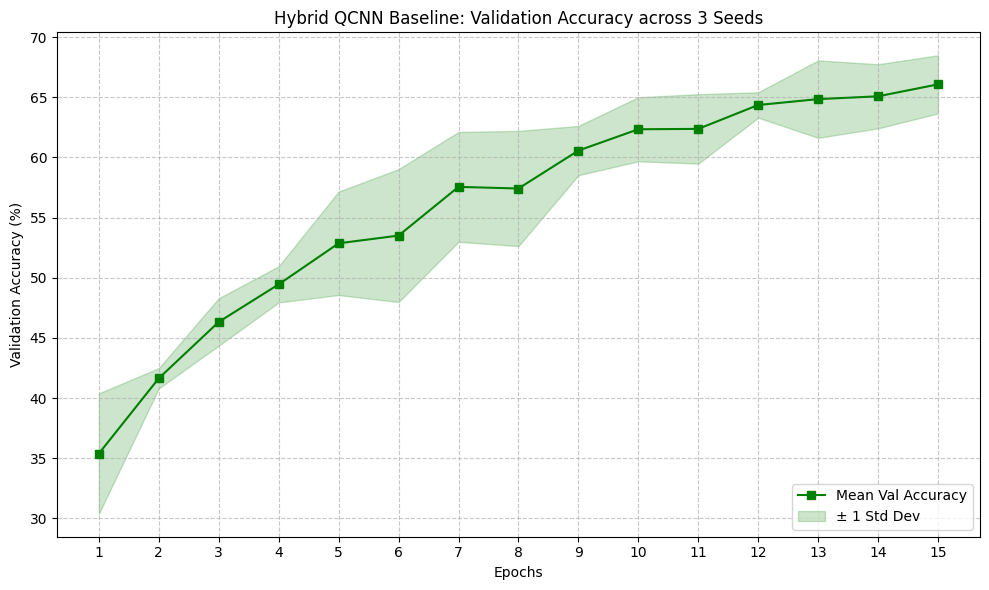

In [9]:
import matplotlib.pyplot as plt
#create an array of epoch numbers for the x-axis
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(10, 6))

#plot the mean validation accuracy
plt.plot(epochs_range, mean_acc, label='Mean Val Accuracy', color='green', marker='s')

#fill the area to show variance
plt.fill_between(
    epochs_range,
    mean_acc - std_acc,
    mean_acc + std_acc,
    color='green',
    alpha=0.2,
    label='± 1 Std Dev'
)

plt.title('Hybrid QCNN Baseline: Validation Accuracy across 3 Seeds')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy (%)')
plt.xticks(epochs_range)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()